In [38]:
## Day -12
## Hour 1
## Block 1
## Title
# House Price Prediction — Final Data Preparation
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("house_price_final_features.csv")
df.head()

## Shape and info
df.shape
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1456 entries, 0 to 1455
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   SalePrice       1456 non-null   int64  
 1   quality_area    1456 non-null   int64  
 2   GarageCars      1456 non-null   int64  
 3   area_per_room   1456 non-null   float64
 4   renovation_age  1456 non-null   int64  
 5   house_age       1456 non-null   int64  
dtypes: float64(1), int64(5)
memory usage: 68.4 KB


Features include engineered variables such as quality_area,
area_per_room, and age-based features.

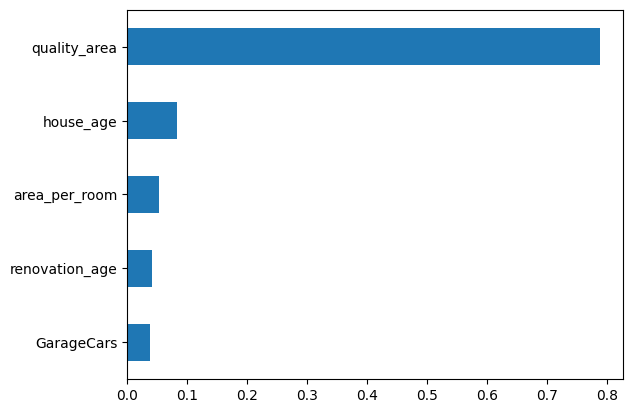

In [39]:
importance_df = pd.read_csv("feature_importance_final.csv", index_col=0)

importance = importance_df.iloc[:, 0]  # convert to Series

importance.sort_values(ascending=True).plot(kind='barh')
plt.show()

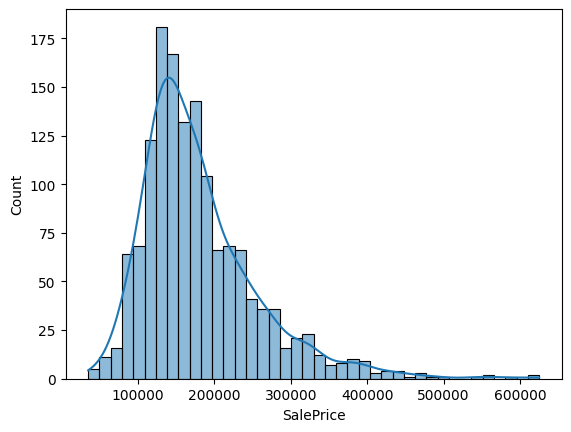

In [40]:
## hour 2
## Check Missing values
df.isnull().sum()

## Check datatypes
df.dtypes

# Check Duplicates
df.duplicated().sum()

# Check feature ranges
df.describe()

# Check feature correlations
df.corr(numeric_only=True)

# Check distribution
import seaborn as sns

sns.histplot(df['SalePrice'], kde=True)
plt.show()

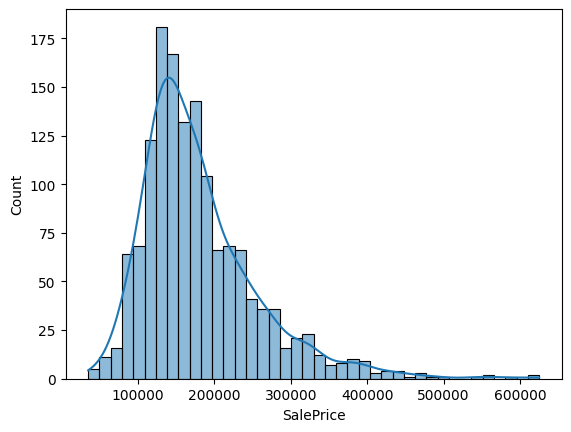

Index(['SalePrice', 'quality_area', 'GarageCars', 'area_per_room',
       'renovation_age', 'house_age', 'SalePrice_log'],
      dtype='object')

In [41]:
# Sale price is right skewed, we can apply log transformation to make it more normal
import numpy as np
df['SalePrice_log'] = np.log1p(df['SalePrice'])
sns.histplot(df['SalePrice'], kde=True)
plt.show()

y = df['SalePrice_log']

df.shape
df.columns

In [42]:
print(df.columns)
df = df.drop(columns=['SalePrice'])
print(df.columns)

Index(['SalePrice', 'quality_area', 'GarageCars', 'area_per_room',
       'renovation_age', 'house_age', 'SalePrice_log'],
      dtype='object')
Index(['quality_area', 'GarageCars', 'area_per_room', 'renovation_age',
       'house_age', 'SalePrice_log'],
      dtype='object')


In [44]:
df = df.rename(columns={'SalePrice_log': 'SalePrice'})
print(df.columns)
df.head()

Index(['quality_area', 'GarageCars', 'area_per_room', 'renovation_age',
       'house_age', 'SalePrice'],
      dtype='object')


,quality_area,GarageCars,area_per_room,renovation_age,house_age,SalePrice
0,11970,2,190.000000,5,5,12.247699
1,7572,2,180.285714,31,31,12.109016
2,12502,2,255.142857,6,7,12.317171
3,12019,3,214.625000,36,91,11.849405
4,17584,3,219.800000,8,8,12.429220


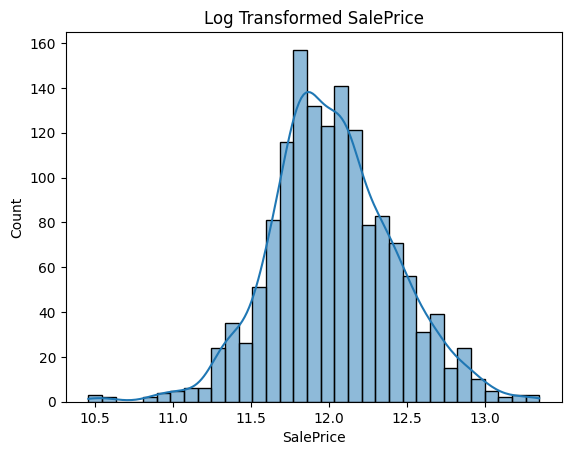

np.float64(0.06546006911025826)

In [46]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df['SalePrice'], kde=True)
plt.title("Log Transformed SalePrice")
plt.show()
df['SalePrice'].skew()

The target variable was highly right-skewed, which was corrected using log transformation, resulting in a near-normal distribution suitable for regression modeling.

Hour 4
Final EDA 

1. Objective
The objective of this analysis is to understand key factors influencing house prices and prepare a clean dataset for predictive modeling.

2. Data Description
The dataset was cleaned by handling missing values and removing low-variance and redundant features. Feature engineering was applied to create meaningful variables 
such as quality_area, area_per_room, and age-based features.

3. Feature Engineering Insight
Feature engineering revealed that combining quality and living area into a single feature (quality_area) significantly improves predictive power compared to individual features.

4. Feature Selection Insight
Feature importance analysis showed that quality_area is the most influential feature, followed by house_age and area efficiency metrics. Redundant features were removed 
to ensure a compact and interpretable feature set.

5. target Variable Insight
The target variable (SalePrice) was highly right-skewed. A log transformation was applied 
to normalize its distribution, improving suitability for regression modeling.

6. Final Dataset Summary
The final dataset contains a small set of highly informative features, ensuring efficient and stable model training.

7. Business Insight
House prices are primarily driven by a combination of property size and quality. 
Additionally, newer and recently renovated houses tend to have higher value, while efficient space utilization also contributes to pricing.

8. Conclusion
A clean and well-engineered dataset was prepared, which is now ready for predictive 
modeling. The analysis highlights the importance of feature engineering in improving 
model performance.

In [50]:
## Hour 5
## dataset v6  final version befor modelling

# Final Refinement
df.columns = df.columns.str.lower()
print(df.columns)

## Rename SalePrice to target
df = df.rename(columns={'saleprice': 'target'})
print(df.columns)

Index(['quality_area', 'garagecars', 'area_per_room', 'renovation_age',
       'house_age', 'saleprice'],
      dtype='object')
Index(['quality_area', 'garagecars', 'area_per_room', 'renovation_age',
       'house_age', 'target'],
      dtype='object')


In [53]:
print(df.shape)
print(df.head())
print(df.isnull().sum())

## After checking
df.to_csv("house_price_v6_final.csv", index=False)

(1456, 6)
   quality_area  garagecars  area_per_room  renovation_age  house_age  \
0         11970           2     190.000000               5          5   
1          7572           2     180.285714              31         31   
2         12502           2     255.142857               6          7   
3         12019           3     214.625000              36         91   
4         17584           3     219.800000               8          8   

      target  
0  12.247699  
1  12.109016  
2  12.317171  
3  11.849405  
4  12.429220  
quality_area      0
garagecars        0
area_per_room     0
renovation_age    0
house_age         0
target            0
dtype: int64


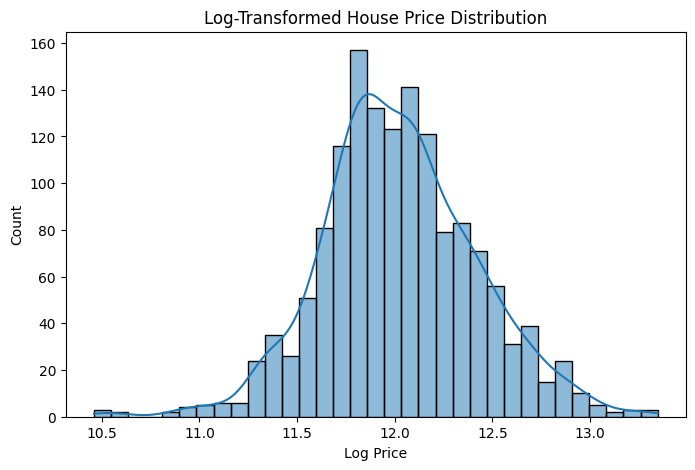

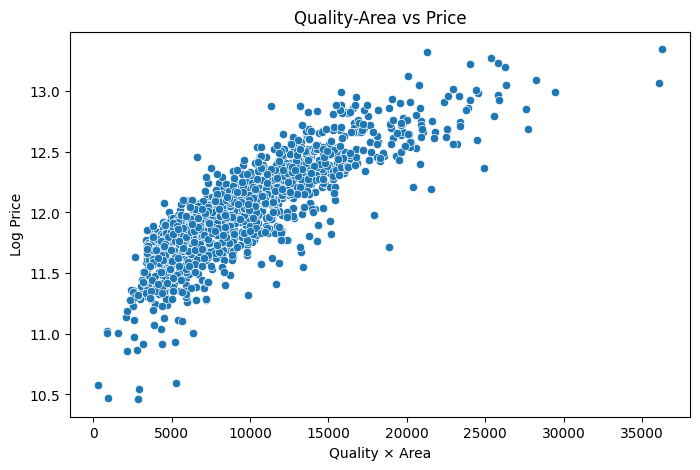

In [ ]:
## Hour 6
## Final Visualization

## Block 1 - Target Distribution
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.histplot(df['target'], kde=True)
plt.title("Log-Transformed House Price Distribution")
plt.xlabel("Log Price")
plt.show()

# ## Insights
# The log-transformed target shows a near-normal distribution,
# improving model stability.

# Most inpfeature vs Target
plt.figure(figsize=(8,5))
sns.scatterplot(x='quality_area', y='target', data=df)
plt.title("Quality-Area vs Price")
plt.xlabel("Quality × Area")
plt.ylabel("Log Price")
plt.show()

# Insight
# Quality-area shows a strong positive 
# relationship with house price.

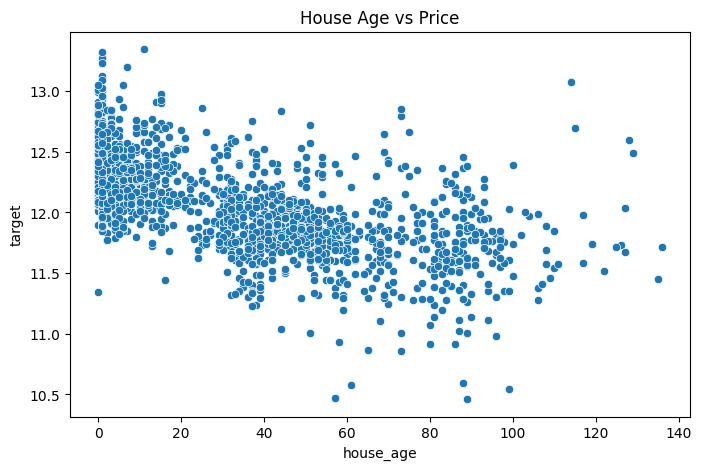

In [ ]:
## Age Effect
plt.figure(figsize=(8,5))
sns.scatterplot(x='house_age', y='target', data=df)
plt.title("House Age vs Price")
plt.show()

## Older houses tend to be cheper.

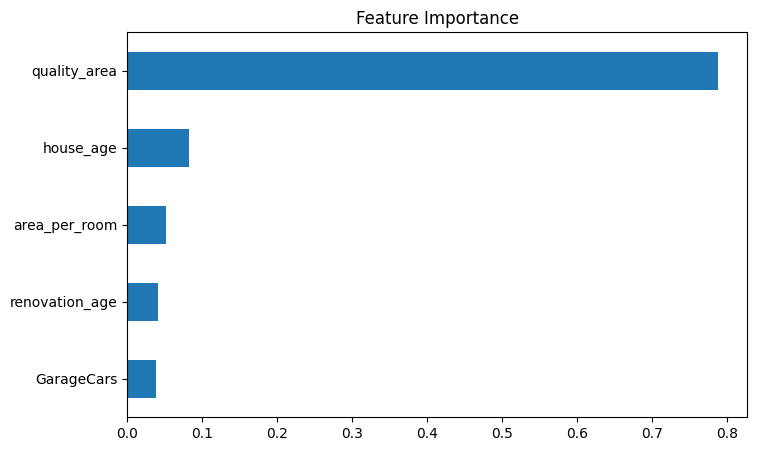

In [57]:
## Feature Importance
plt.figure(figsize=(8,5))
importance.sort_values().plot(kind='barh')
plt.title("Feature Importance")
plt.show()

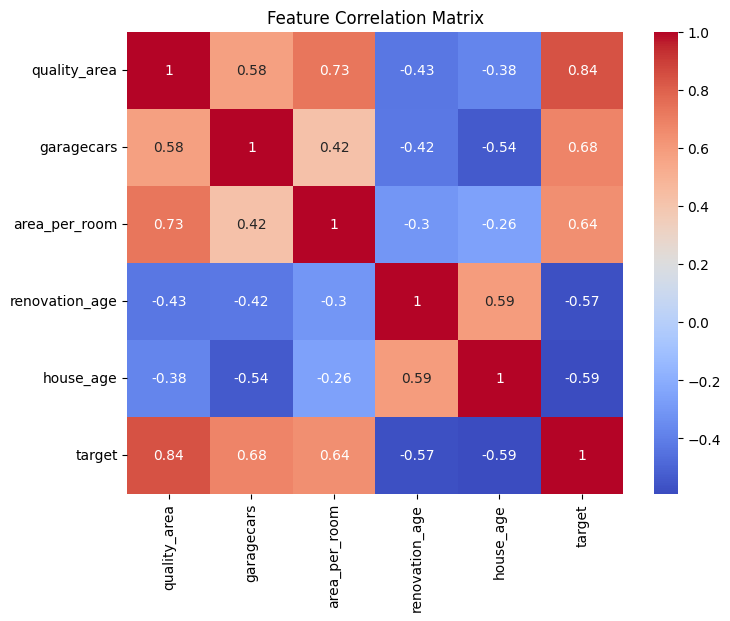

In [ ]:
## Correlation Hatmap
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Feature Correlation Matrix")
plt.show()

# Features show meaningful relationships 
# without extreme redundancy.